## **Dependencies**

In [1]:
import os
import sys
import json
import glob
import joblib

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from transformers import AutoTokenizer, AutoModelForCausalLM

import xgboost as xgb
import shap
from PIL import Image

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("my_hf_token")

from huggingface_hub import login
login(token=hf_token)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## **Configurations**

In [4]:
# Raw datasets (original data, for pulling sample inputs)
MALMEM_CSV        = "/kaggle/input/datasets/bertvankeulen/cic-malmem-2022/MalMem2022.csv"
API_CSV           = "/kaggle/input/datasets/ang3loliveira/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv"
MALEVIS_DIR       = "/kaggle/input/datasets/sohamkumar1703/malevis-dataset/malevis_train_val_300x300"

# Artifact datasets (model files + preprocessing pipelines)
ARTIFACTS_XGB      = "/kaggle/input/datasets/anarvaaa/artifacts-for-xgboost"
ARTIFACTS_TRANSFORMER = "/kaggle/input/datasets/anarvaaa/artifacts-for-transformer"
ARTIFACTS_CNN = "/kaggle/input/datasets/anarvaaa/artifacts-for-cnn"

# Security Documents
MITRE_ATTACK_JSON = r"/kaggle/input/datasets/anarvaaa/security-documentations/enterprise-attack-19.1.json"
LOCAL_DOCS = "/kaggle/input/datasets/anarvaaa/security-documentations/security_docs.json"

# LLM Model and HF tokens
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
HF_TOKEN = hf_token

In [5]:
# XGBoost Artifact Paths
xgb_pipeline_path = os.path.join(ARTIFACTS_XGB, "preprocessing_pipeline.joblib")
xgb_encoder_path  = os.path.join(ARTIFACTS_XGB, "label_encoder.joblib")
xgb_model_path    = os.path.join(ARTIFACTS_XGB, "calibrated_xgboost_model.joblib")

# Transformer Artifact Paths
transformer_pipeline_path     = os.path.join(ARTIFACTS_TRANSFORMER, "transformer_preprocessing_pipeline.json")
transformer_model_path        = os.path.join(ARTIFACTS_TRANSFORMER, "api_transformer_model.pth")
transformer_platt_scalar_path = os.path.join(ARTIFACTS_TRANSFORMER, "transformer_platt_scaler.joblib")

# CNN Artifacts Paths
cnn_pipeline_path    = os.path.join(ARTIFACTS_CNN, "cnn_preprocessing_pipeline.json")
cnn_model_path       = os.path.join(ARTIFACTS_CNN, "malevis_cnn_model.pth")
cnn_calibration_path = os.path.join(ARTIFACTS_CNN, "cnn_platt_calibrators.joblib")
cnn_class_weights    = os.path.join(ARTIFACTS_CNN, "cnn_class_weights.json")

In [6]:
# Helper Functions
sys.path.append("/kaggle/input/datasets/anarvaaa/utilities")

from inference_functions import (xgboost_calibrated_inference,transformer_calibrated_inference,cnn_calibrated_inference,device,)
from combining_logic import total_maliciousness
from fixed_config import (max_limit_files, per_class_limit, hierarchy,xgb_per_class_fscores, xgb_weighted_f1score,transformer_per_class_fscores, transformer_weighted_f1score,API_Calls,)
from security_docs import load_security_references, assemble_context_snippets
from prompt_generation import generate_soc_report
from json_summary_generator import build_final_summary
from timeline_runner import PipelineContext, run_timeline
from rolling_maliciousness import RollingMaliciousnessTracker

## **Initializations**

In [7]:
# Converting Malevis directory to list-like format to grab a file by index later (CNN)
sample_image_candidates = glob.glob(os.path.join(MALEVIS_DIR, "**", "*.png"), recursive=True)
if not sample_image_candidates:
    sample_image_candidates = glob.glob(os.path.join(MALEVIS_DIR, "**", "*.jpg"), recursive=True)

# Loading Malmem 2022 dataset (xgboost)
df_malmem = pd.read_csv(MALMEM_CSV)

# Loading API Call dataset (transformer)
df_api = pd.read_csv(API_CSV)
seq_cols = [c for c in df_api.columns if c.startswith('t_')]

In [8]:
# Load the precomputed w_normalized class weights (saved by the training notebook),
# so score_calc can look them up by class name -- cnn_class_weights above is just the
# file PATH, this loads its actual contents.
with open(cnn_class_weights, "r") as f:
    cnn_class_weights_data = json.load(f)

In [9]:
# Load MITRE ATT&CK + local SECURITY_DOCS grounding references
# (indexes are built inside security_docs.py; LOCAL_DOCS points at the
# security_docs.json file uploaded in the security_documentations dataset)
load_security_references(MITRE_ATTACK_JSON, LOCAL_DOCS)

Loaded MITRE ATT&CK data: 25843 STIX objects
MITRE indexes ready: 1581 techniques, 992 software entries, 602 group entries
Loaded local SECURITY_DOCS: 24 entries across 3 categories


In [10]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN,
    dtype=torch.float16,
    device_map="auto",
)

model.eval()

DEVICE = next(model.parameters()).device
NUM_LAYERS = model.config.num_hidden_layers
HIDDEN_DIM = model.config.hidden_size

print(
    f"Loaded {MODEL_NAME}: "
    f"{NUM_LAYERS} layers, "
    f"hidden_dim={HIDDEN_DIM}, "
    f"device={DEVICE}"
)

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loaded meta-llama/Llama-3.2-3B-Instruct: 28 layers, hidden_dim=3072, device=cuda:0


## **Input**

In [11]:
evidence_sequence = {                                  # XGBoost, Transformer, CNN
    "t10": [332, 38, []],                               # benign, benign, no suspicious files
    "t20": [332, 15, []],                               # benign, benign, no suspicious files
    "t30": [3232, 15, [0]],                             # benign, benign, [Amonetize] files found
    "t40": [3232, 115, [0,1814]],                       # benign, malware, [Amonetize, Expiro] files found
    "t50": [50000, 115, [1814, 1815, 614]],             # trojan, malware, [Expiro, Expiro, Androm] files found
    "t60": [50000, 15, [1815]],                         # trojan, benign, [Expiro] files found
    "t70": [35374, 143, [182, 183, 0, 1815]],           # ransomware, malware, [HackKMS, HackKMS, Amonetize, Expiro] files found
    "t80": [35374, 143, [616, 183]],                    # ransomware, malware, [Neshta, HackKMS] files found
    "t90": [332, 38, [606]],                            # benign, benign, [other] files found
    "t100": [45000, 143, [617, 606, 614]]               # spyware, malware, [Statinko, other, Androm] files found
}

## **Run**

In [12]:
ctx = PipelineContext(
    df_malmem=df_malmem, df_api=df_api, seq_cols=seq_cols,
    sample_image_candidates=sample_image_candidates,
    xgb_model_path=xgb_model_path, xgb_pipeline_path=xgb_pipeline_path, xgb_encoder_path=xgb_encoder_path,
    transformer_model_path=transformer_model_path, transformer_platt_scalar_path=transformer_platt_scalar_path,
    transformer_pipeline_path=transformer_pipeline_path, api_calls_mapping=API_Calls,
    cnn_model_path=cnn_model_path, cnn_pipeline_path=cnn_pipeline_path, cnn_calibration_path=cnn_calibration_path,
    cnn_class_weights_data=cnn_class_weights_data,
    xgb_per_class_fscores=xgb_per_class_fscores, transformer_per_class_fscores=transformer_per_class_fscores,
    hierarchy=hierarchy, max_limit_files=max_limit_files, per_class_limit=per_class_limit,
    tokenizer=tokenizer, model=model, device=DEVICE,
)

In [13]:
tracker = RollingMaliciousnessTracker(alpha=0.3)  # tune alpha
history = run_timeline(evidence_sequence, ctx, on_step=tracker.step)

SOC ANALYST REPORT at T=10 units

**VERDICT**
The system indicates a low-level benign process with a final probability of 0.0228.

**FINDINGS BY DETECTOR**

* XGBoost: The model predicts a benign process state with a confidence of 0.95, indicating that the system's memory forensics do not detect any malicious artifacts.
* Transformer: The model classifies the sequence of Windows API/syscalls as goodware/benign with a confidence of 0.888, suggesting that the system's behavior is not indicative of malicious activity.
* CNN: No evidence is provided by the CNN detector, as it only reports on scanned files and influential files, which are not present in this case.

**ATTACK CONTEXT**

The flagged RAM state indicates that the process count, handle count, and DLL load patterns are within normal baseline ranges for the sampled memory image, according to the MITRE ATT&CK documentation. This suggests that the system's memory forensics do not detect any malicious artifacts.

**CONFIDENCE & DISAGR

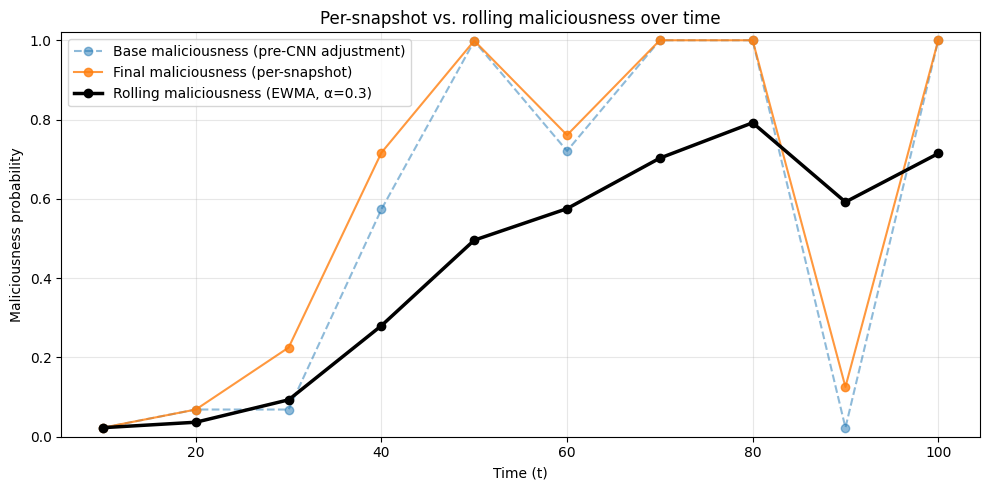

In [14]:
ts = [h["t"] for h in history]
base_vals = [h["base_P_mal"] for h in history]
final_vals = [h["final_P_mal"] for h in history]
rolling_vals = [h["rolling_final_P_mal"] for h in history]

plt.figure(figsize=(10, 5))
plt.plot(ts, base_vals, marker="o", linestyle="--", alpha=0.5, label="Base maliciousness (pre-CNN adjustment)")
plt.plot(ts, final_vals, marker="o", alpha=0.8, label="Final maliciousness (per-snapshot)")
plt.plot(ts, rolling_vals, marker="o", linewidth=2.5, color="black", label=f"Rolling maliciousness (EWMA, α={tracker.alpha})")

plt.xlabel("Time (t)")
plt.ylabel("Maliciousness probability")
plt.title("Per-snapshot vs. rolling maliciousness over time")
plt.ylim(0, 1.02)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()